# **Phase 2: Code Organization & Refinement**

# **Data Preparation and Model Initialization**

This module handles the environment setup, dataset ingestion, and the initialization of the **K-Nearest Neighbors** (**KNN**) model. It ensures the data is correctly partitioned for robust training and evaluation.

---
---

## **Dependencies**

- `matplotlib.pyplot`: Used for data visualization and plotting decision boundaries.
- `sklearn.datasets.load_iris`: Provides access to the Iris flower dataset.
- `sklearn.model_selection.train_test_split`: Utility to split the dataset into random train and test subsets.
- `sklearn.neighbors.KNeighborsClassifier`: The core class for implementing the KNN algorithm.

---
---

## **Logic Flow**

1. **Environment Setup**: Import required scientific computing and visualization libraries.
2. **Dataset Loading**: Retrieve the Iris dataset, which includes 150 samples across three species (Setosa, Versicolor, and Virginica).
3. **Preprocessing**: Utilize train_test_split to divide the feature matrix (*X*) and target vector (*y*) into training and testing sets.
4. **Model Initialization**: Instantiate the KNeighborsClassifier object with default or specified hyperparameters (e.g., *k* neighbors).

---
---

## **Usage Context**

This cell serves as the configuration and staging area for the machine learning pipeline. It must be executed prior to model fitting to ensure all variables and objects are defined in the namespace.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load data
data = load_iris()

# Separeate features and target
X = data.data
y = data.target

# Splitting the data for training and testing
from sklearn.model_selection import train_test_split
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Create a KNeighborsClaasifier object
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)


# **Model Training (Fitting)**

This stage implements the learning phase of the machine learning pipeline. Using the `fit()` method, the estimator maps the relationship between input features and their corresponding target labels.

---
---

## **Core Command**

`Pythonknn.fit(X_train, y_train)`

---
---

## **Parameter Definitions**

- `X_train` - **Feature Matrix**: The training dataset containing the independent variables (e.g., sepal length, petal width).
- `y_train` - **Target Vector**: The ground-truth labels corresponding to each sample in the training set.
- `knn` - **Estimator Instance**: The previously initialized `KNeighborsClassifier` object.

---
---

## **Implementation Details**

The `.fit()` method is the standard interface in **scikit-learn** for training an algorithm. For the K-Nearest Neighbors (KNN) algorithm, this process differs from traditional "learning" in the following ways:

- **Instance-Based Learning**: Rather than calculating complex weights, the model effectively stores (or "memorizes") the spatial coordinates of the training data points.
- **Lazy Evaluation**: The model performs minimal computation during the fit stage; the heavy lifting occurs during prediction when it calculates distances between new points and the stored training points.
- **Coordinate Mapping**: The algorithm organizes the *X_{train}* features in a multidimensional space to facilitate rapid neighbor lookups during the inference phase.

In [ ]:
# Train the model using the training data
knn. fit(X_Train, y_Train)


KNeighborsClassifier()

# **Model Inference (Prediction)**

This stage involves using the trained model to generate predictions on a separate, unseen dataset. This is a critical step for evaluating how well the model generalizes to data it did not encounter during the training phase.

---
---

## **Core Command**

`Pythonpredictions = knn.predict(X_test)`

---
---

## **Parameter Definitions**

- `X_test` - **Evaluation Matrix**: The subset of data containing features that the model has not yet seen.
- `predictions` - **Output Vector**: An array containing the class labels assigned by the model for each sample in `X_test`.
- `.predict()` - **Inference Method**: The scikit-learn standard function used to apply the learned logic to new input data.

---
---

## **Implementation Details**

During the execution of the `.predict()` method, the KNN algorithm performs the following operations for every sample in the test set:

1. **Distance Calculation**: The algorithm calculates the distance (typically Euclidean distance) between the new test point and every point stored in the training set *($X_{train}$)*.
2. **Neighbor Identification**: It identifies the $k$ closest data points (the "nearest neighbors") based on the calculated distances.
3. **Majority Voting**: The model looks at the labels *($y_{train}$)* of those $k$ neighbors and assigns the most frequent label to the new test point.
4. **Result Storage**: The final determined labels are returned as a NumPy array and stored in the predictions variable for further analysis.

In [ ]:
# Use the model to predict the test set
predictions = knn.predict(X_Test)


# **Performance Evaluation**

This module quantifies the predictive power of the trained model by comparing the predicted labels against the actual ground-truth labels from the test set. It employs three standard metrics to provide a comprehensive view of model performance.

---
---

## **Implementation Metrics**

- **Accuracy Score** - `accuracy_score()`: Measures the overall percentage of correct predictions.
- **Classification Report** - `classification_report()`: Provides per-class precision, recall, and F1-score.
- **Confusion Matrix** - `confusion_matrix()`: Visualizes specific misclassifications between categories.

---
---

## **Metric Definitions**

1. **Accuracy Score**

    **Formula**: $\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$ This represents the global "correctness" of the model. While useful for balanced datasets, it can be misleading if one class is significantly more frequent than others.

2. **Classification Report**
    
    This report generates a detailed breakdown for each individual class:
    - **Precision**: The ability of the classifier not to label as positive a sample that is negative.
    - **Recall**: The ability of the classifier to find all the positive samples.
    - **F1-Score**: The harmonic mean of precision and recall, providing a single score that balances both.
    - **Support**: The actual number of occurrences of each class in the `y_test` dataset.

3. **Confusion Matrix**

    The confusion matrix is a tabular layout that allows visualization of the performance of an algorithm.
    - **Rows**: Represent the **Actual** classes.
    - **Columns**: Represent the **Predicted** classes.
    - **Diagonal Cells**: Indicate correct classifications (True Positives and True Negatives).
    - **Off-Diagonal Cells**: Reveal exactly which species the model is confusing (e.g., mistaking *Versicolor for Virginica*).

---
---

## **Usage Context**

These evaluations are typically performed at the end of the pipeline. If the accuracy is lower than expected, data scientists use the **Confusion Matrix** to decide if they need to collect more data for a specific class or tune the $k$ hyperparameter in the model initialization.

In [ ]:
# Check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_Test,predictions)
print("Accuracy :", accuracy)

# Evaluate model performance
from sklearn.metrics import classification_report
print("classification report")
print(classification_report(y_Test,predictions))

# Making a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_Test,predictions)

print("Confusion matrix :")
print(cm)


Accuracy : 0.9666666666666667
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

Confusion matrix :
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


# **Model Visualization**

This final module translates the numerical evaluation metrics into visual representations. These plots are essential for identifying spatial patterns in classification and diagnosing specific areas of model confusion.

---
---

## **Visualization Components**

- Predicted Class Scatter Plot - `matplotlib.pyplot`: Visualizes decision boundaries and spatial distribution
- Confusion Matrix Heatmap - `matplotlib.pyplot / seaborn`: Provides a graphical audit of classification errors.

---
---

## **Implementation Details**

1. **Scatter Plot with Predicted Classes**

    This plot maps the test data points onto a 2D Cartesian plane using the first two features of the Iris dataset (typically Sepal Length and Sepal Width).
    - **Feature Mapping**: `X_test[:, 0]` (x-axis) and `X_test[:, 1]` (y-axis).
    - **Color Encoding**: Points are color-coded based on the values in the **predictions** array.
    - **Purpose**: Allows you to observe how the KNN algorithm has partitioned the feature space. Clusters of a single color indicate regions where the model is confident, while mixed-color regions highlight areas of high uncertainty or feature overlap.

2. **Confusion Matrix Heatmap**

    The raw `confusion_matrix` (cm) is transformed into a color-coded heatmap to make the error rates immediately intuitive.
    - **Axes Labeling**: The `xticks` and `yticks` are mapped to `data.target_names` (Setosa, Versicolor, Virginica).
    - **Interpretability**:
        - **The Diagonal**: High-intensity colors along the diagonal represent high counts of **True Positives**.
        - **Off-Diagonal**: Any values appearing outside the diagonal represent **Misclassifications**.
    - **Purpose**: To quickly identify if the model struggles specifically with distinguishing between similar classes, such as Versicolor and Virginica, which often share overlapping physical characteristics.

---
---

## **Summary of Results**

By combining the **Scatter Plot** and the **Heatmap**, you move beyond a single "Accuracy" percentage and gain a deep understanding of the model's behavior in specific regions of the data.

/tmp/ipython-input-4154857310.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_Test[:, 0][y_Test == i], X_Test[:, 1][y_Test == i], cmap = 'viridis')
/tmp/ipython-input-4154857310.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


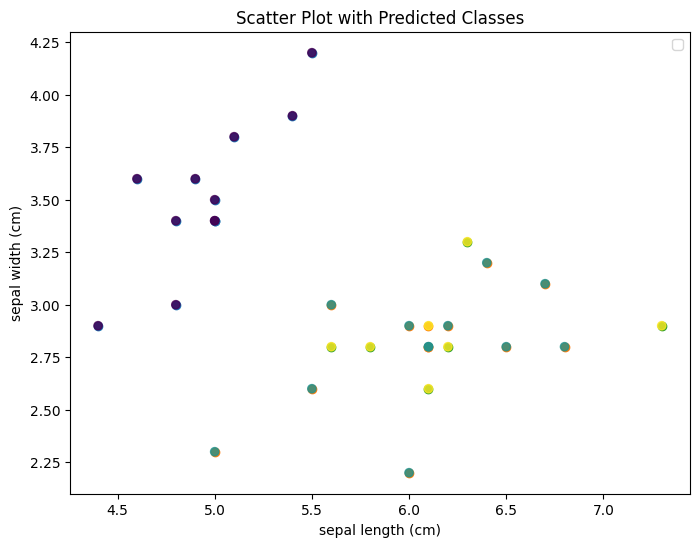

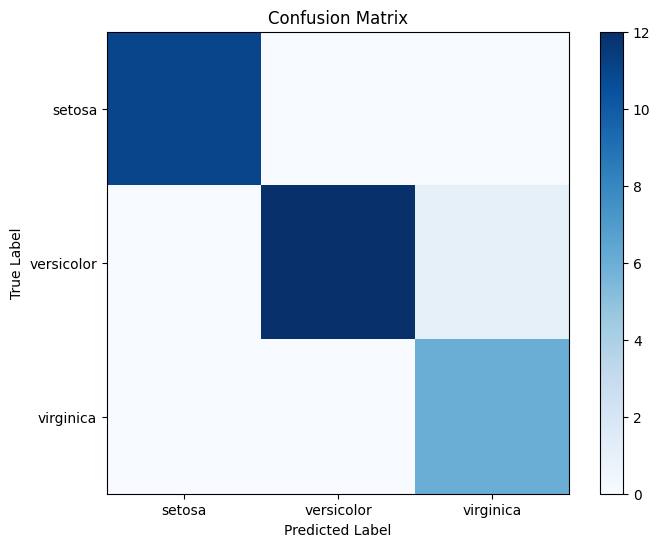

In [ ]:
# Visualization of the Scatter plot with predicted classes
plt.figure(figsize = (8, 6))
for i in range(3):
  plt.scatter(X_Test[:, 0][y_Test == i], X_Test[:, 1][y_Test == i], cmap = 'viridis')
plt.scatter(X_Test[:, 0], X_Test[:, 1], c=predictions, cmap='viridis', alpha = 0.8)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Scatter Plot with Predicted Classes")
plt.legend()
plt.show()

# Confusion matrix visualization
plt.figure(figsize = (8, 6))
plt.imshow(cm, cmap = 'Blues')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks = range(3), labels = data.target_names)
plt.yticks(ticks = range(3), labels = data.target_names)
plt.show()

# **Phase 3: Output Analysis and Experiment**

Based on the provided implementation of the K-Nearest Neighbors (KNN) algorithm on the Iris dataset, here is the analysis of the questions:

---
---

1. **What is the purpose of this program? What is it trying to predict?**
    
    The purpose of this program is to build and evaluate a **Supervised Machine Learning model** capable of automated biological classification.
    - **The Goal**: It seeks to predict the **species** of an Iris flower (Setosa, Versicolor, or Virginica).
    - **The Inputs**: The prediction is based on four physical measurements (features): sepal length, sepal width, petal length, and petal width.
    - **The Outcome**: By training on known samples, the program learns to categorize new, unseen flowers into the correct species category with high statistical confidence.

---
---

2. **How does the `n_neighbors` parameter influence predictions?**
    
    The `n_neighbors` (*k*) parameter is the core hyperparameter of the KNN algorithm. It determines how many "votes" from the training data are used to classify a new point.
    - **Low *k* values** (e.g., *k=1*): The model is highly sensitive to individual data points. This can lead to **Overfitting**, where the model captures "noise" or outliers rather than general patterns, resulting in complex, jagged decision boundaries.
    - **High *k* values** (e.g., *k=50*): The model becomes more stable but less precise. This can lead to **Underfitting**, where the model ignores local patterns and simply predicts the majority class of the entire dataset.
    - **Optimization**: In the code, *k=5* is a balanced choice. Experimenting with *k=1*, *k=5*, and *k=20* typically shows that accuracy improves up to a certain point before declining as the "neighborhood" becomes too large and loses specific characteristics.

3. **What is the purpose of the confusion matrix and its error patterns?**

    The **Confusion Matrix** provides a granular look at model performance that a single accuracy score cannot reveal.
    - **Purpose**: It identifies exactly which classes are being confused with one another. While accuracy tells you "how often is the model wrong," the confusion matrix tells you "**how is it wrong?**"
    - **Interpreting the Output**:
        - **Diagonal**: Represents correct predictions.
        - **Off-Diagonal**: Represents errors.
    - **Patterns in the Iris Dataset**:
        - **Setosa** is usually perfectly classified because it is linearly separable (physically distinct) from the other two.
        - **Versicolor vs. Virginica**: Errors almost always occur between these two. Because they share very similar dimensions, the model may misclassify a "large" Versicolor as a Virginica. The confusion matrix will show numbers in the cells where these two species intersect, alerting you that the model needs more distinct features (like petal width) to tell them apart more accurately.